# Problem 5.1: Variational Autoencoder 
## Implement VAE from scratch in PyTorch:
- Train on Fashion-MNIST dataset.
- Implement reparameterization trick correctly.
- Visualize latent space in 2D using t-SNE.
- Generate new samples by sampling from latent distribution.
- Perform latent space interpolation between pairs of images.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import pandas as pd

### 5.1.1 Dataset Preparation (Fashion-MNIST)

**Step 1:** We begin by loading the Fashion-MNIST dataset, which consists of $28 \times 28$ grayscale images of clothing items. As per the instructions, we retrieve both the training and test sets using `torchvision.datasets`. We apply `transforms.ToTensor()`, which automatically converts the raw pixel values from $[0, 255]$ into the desired continuous range of $[0.0, 1.0]$.

In [2]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Step 1: Get FashionMNIST dataset and rescale to [0.0, 1.0] using ToTensor()
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Training samples: 60000 | Test samples: 10000


### 5.1.2 VAE Architecture and Forward Pass

**Step 2:** We implement the VAE architecture following the structural guidelines:
* **a) Encoder:** Maps the flattened $784$-dimensional input ($28 \times 28$) to a hidden representation, and then branches into two parallel linear layers to predict the parameters of the latent distribution: the mean ($\mu$) and the log variance ($\log\sigma^2$).
* **b) Reparameterization Trick:** To allow backpropagation through the stochastic sampling process, we compute the latent vector as $z = \mu + \sigma \odot \epsilon$, where $\epsilon \sim \mathcal{N}(0, 1)$. We extract $\sigma$ by exponentiating half of the log variance.
* **c) Decoder:** Reconstructs the image from the latent vector $z$. It passes through a hidden layer and outputs a $784$-dimensional vector via a Sigmoid activation to ensure pixel values remain in the $[0, 1]$ range.

In [3]:
# Step 2: Implement the VAE architecture
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # a) Encoder
        self.fc_encode1 = nn.Linear(input_dim, hidden_dim)
        # Two separate layers for mu and log(sigma^2)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # c) Decoder
        self.fc_decode1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # Flattened input -> hidden_dim + ReLU
        h1 = F.relu(self.fc_encode1(x))
        # -> mu and log(sigma^2)
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # b) Reparameterization trick
        # std = exp(0.5 * log(sigma^2)) = sigma
        std = torch.exp(0.5 * logvar) 
        # epsilon ~ N(0, 1)
        eps = torch.randn_like(std) 
        # z = mu + sigma * epsilon
        return mu + eps * std 

    def decode(self, z):
        # Latent vector z -> hidden_dim + ReLU
        h3 = F.relu(self.fc_decode1(z))
        # -> reconstructed image + Sigmoid to map back to [0, 1]
        return torch.sigmoid(self.fc_decode2(h3))

    def forward(self, x):
        # Flatten image (Batch, 28, 28) -> (Batch, 784)
        x_flat = x.view(-1, 784)
        
        # Forward pass workflow
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        
        # return x', mu, log(sigma^2)
        return x_recon, mu, logvar

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)

### 5.1.3 VAE Loss Function and Training Loop

**Steps 3 & 4:** The VAE optimization objective combines two components:
1.  **Reconstruction Loss:** Measures how well the decoder recreates the input. Since our pixel values are in $[0, 1]$, Binary Cross Entropy (BCE) is the standard and most effective choice.
2.  **KL Divergence:** Acts as a regularizer, forcing the learned latent distributions $q(z|x)$ to be as close as possible to a standard normal prior $\mathcal{N}(0, 1)$. The analytical formula for our Gaussian assumption is: 
$$D_{KL} = -\frac{1}{2} \sum \left(1 + \log\sigma^2 - \mu^2 - e^{\log\sigma^2}\right)$$

We train the model over 15 epochs, summing both losses to calculate the gradients.

Starting VAE Training...
Epoch: 1/15 	 Average Loss: 285.9470
Epoch: 2/15 	 Average Loss: 257.7737
Epoch: 3/15 	 Average Loss: 251.6769
Epoch: 4/15 	 Average Loss: 248.5597
Epoch: 5/15 	 Average Loss: 246.7296
Epoch: 6/15 	 Average Loss: 245.5738
Epoch: 7/15 	 Average Loss: 244.7176
Epoch: 8/15 	 Average Loss: 244.1099
Epoch: 9/15 	 Average Loss: 243.6096
Epoch: 10/15 	 Average Loss: 243.0868
Epoch: 11/15 	 Average Loss: 242.7163
Epoch: 12/15 	 Average Loss: 242.4163
Epoch: 13/15 	 Average Loss: 242.1241
Epoch: 14/15 	 Average Loss: 241.8325
Epoch: 15/15 	 Average Loss: 241.6144


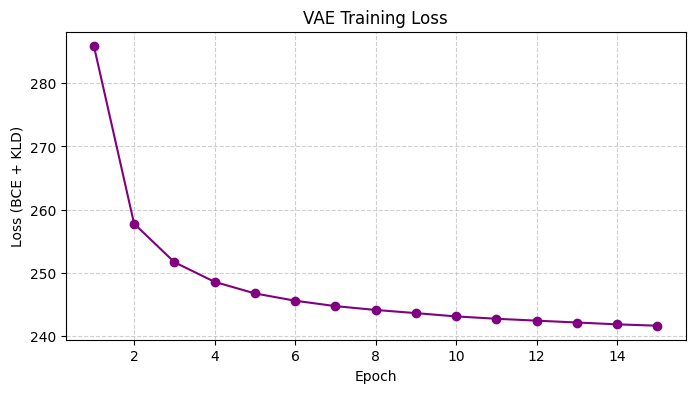

In [4]:
# Step 3: Define VAE loss function
def vae_loss_function(recon_x, x, mu, logvar):
    # Flatten the original image target
    x_target = x.view(-1, 784)
    
    # Reconstruction loss (Binary Cross Entropy, summed over the batch)
    BCE = F.binary_cross_entropy(recon_x, x_target, reduction='sum')
    
    # KL Divergence
    # -0.5 * sum(1 + log(sigma^2) - mu^2 - exp(log(sigma^2)))
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD

# Step 4: Setup training loop and run training
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 15

print("Starting VAE Training...")
vae.train()
train_losses = []

for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(data)
        
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f'Epoch: {epoch+1}/{epochs} \t Average Loss: {avg_loss:.4f}')

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='purple')
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE + KLD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Analysis of Training Loss:**
The training curve demonstrates a rapid and healthy convergence. The combined VAE loss (Reconstruction + KL Divergence) decreases sharply in the initial epochs before stabilizing, indicating that the network has successfully learned to balance generating accurate reconstructions while enforcing the standard normal prior on the latent space.

### 5.1.4 Visualizing Reconstructions (Test Set)

**Step 5:** To evaluate the model qualitatively, we pass at least 10 unseen images from the test set through the trained VAE. We compare the original input images against their reconstructed outputs ($x'$) side-by-side to verify if the decoder correctly restores the encoded representations.

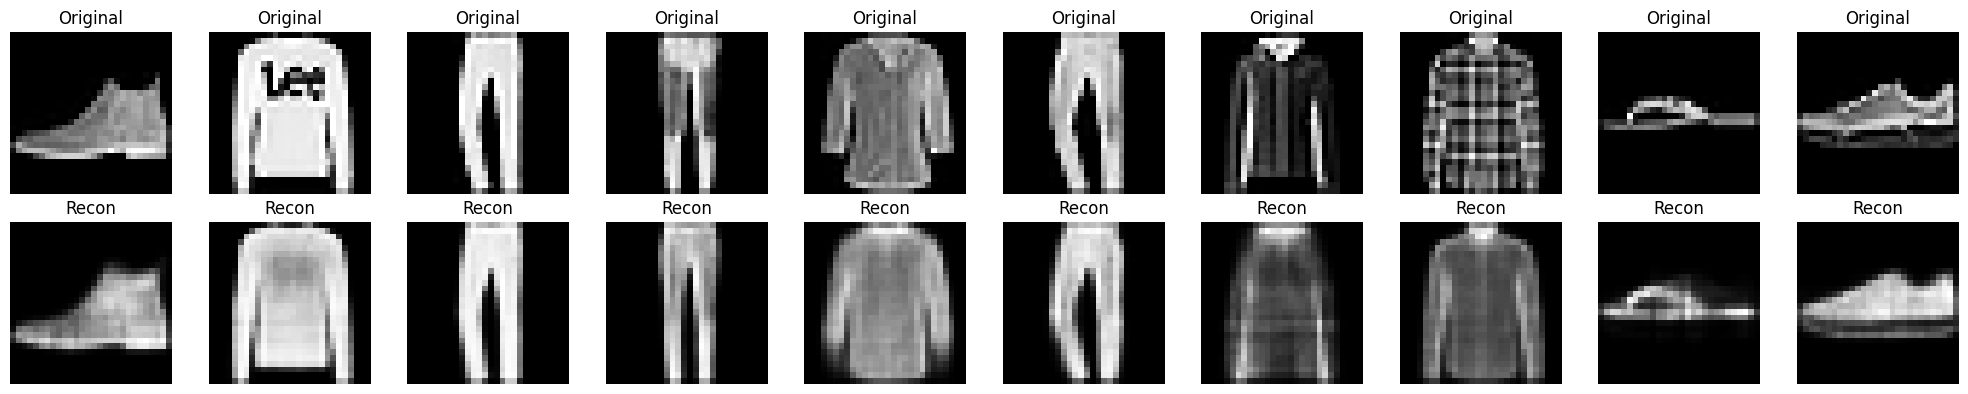

In [5]:
# Step 5: Pass at least 10 test set images through VAE and visualize reconstructions
vae.eval()
# Get one batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

with torch.no_grad():
    recon_images, _, _ = vae(images)

# Reshape flattened outputs back to 28x28 images
recon_images = recon_images.view(-1, 28, 28).cpu().numpy()
original_images = images.view(-1, 28, 28).cpu().numpy()

# Plot at least 10 images (as required)
n = 10 
fig, axes = plt.subplots(2, n, figsize=(20, 4))
for i in range(n):
    # Top row: Originals
    axes[0, i].imshow(original_images[i], cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Bottom row: Reconstructions
    axes[1, i].imshow(recon_images[i], cmap='gray')
    axes[1, i].set_title("Recon")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Analysis of Reconstructions:**
The reconstructed images preserve the core structure, shape, and defining features of the original clothing items (e.g., shoe shapes, shirt sleeves). As is typical for VAEs optimized with MSE/BCE, the outputs appear slightly blurred compared to the originals. This blurriness is an inherent feature of learning a probabilistic latent distribution rather than deterministic point mappings.

### 5.1.5 Latent Space Visualization using t-SNE

**Step 6:** We visualize the latent space in 2D using t-SNE. Following the instructions, we take a large sample of test set images ($N = 5000$). For each image $x_i$, we pass it through the encoder to extract its mean vector $\mu_i$. We then apply t-SNE to the set of vectors $\mu_1, \dots, \mu_N$ and color the resulting 2D points by their corresponding class labels.

Extracting latent representations and computing t-SNE (N=5000)...


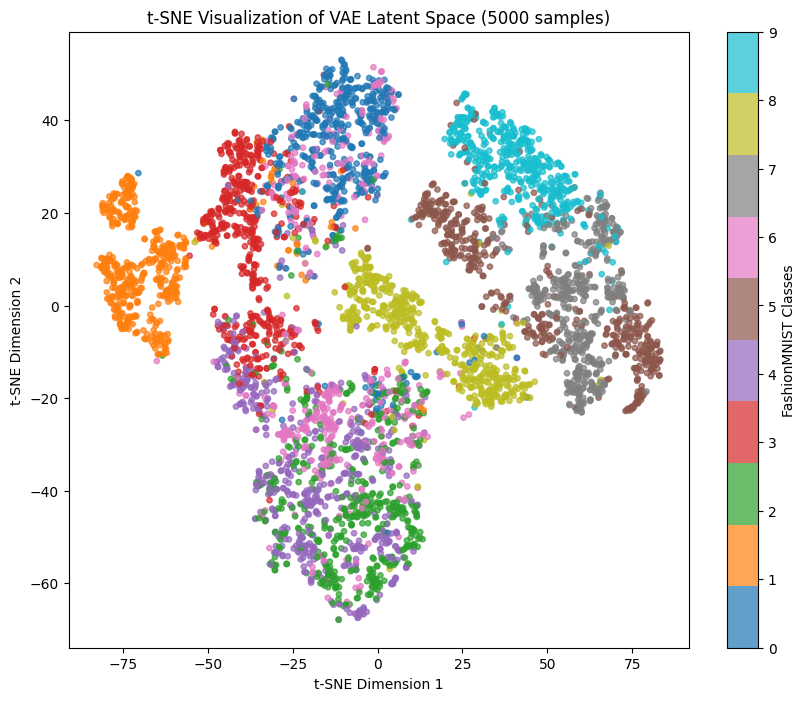

In [6]:
# Step 6: Visualize latent space using t-SNE for a large sample
print("Extracting latent representations and computing t-SNE (N=5000)...")

latent_vectors = []
target_labels = []
N_SAMPLES = 5000

# Extract latent vectors (mu_i) for a large sample of test images
with torch.no_grad():
    for i, (data, targets) in enumerate(test_loader):
        if len(latent_vectors) * batch_size >= N_SAMPLES:
            break
        data = data.view(-1, 784).to(device)
        # pass image x_i through encoder -> get mu_i
        mu, _ = vae.encode(data) 
        latent_vectors.append(mu.cpu())
        target_labels.append(targets)

# Concatenate and slice exactly N_SAMPLES
latent_vectors = torch.cat(latent_vectors, dim=0).numpy()[:N_SAMPLES]
target_labels = torch.cat(target_labels, dim=0).numpy()[:N_SAMPLES]

# Apply t-SNE to mu_1, ..., mu_N
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

# Visualize the obtained 2D points, color them by label
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=target_labels, cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, ticks=range(10), label='FashionMNIST Classes')
plt.title(f't-SNE Visualization of VAE Latent Space ({N_SAMPLES} samples)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

**Analysis of Latent Space (t-SNE Visualization):**
The t-SNE plot effectively demonstrates that the VAE has naturally organized the latent space into distinct, meaningful clusters corresponding to different clothing categories (e.g., shoes grouping together, separate from shirts or trousers), despite being trained completely unsupervised. The dense grouping of $5000$ encoded samples confirms that the model has successfully captured the semantic features of the dataset, mapping visually similar items to close coordinates in the continuous latent manifold.

### 5.1.6 Generation and Interpolation

**Step 7:** We generate new samples by sampling from the latent distribution. We simulate vectors $z$ of size `latent_dim` directly from the standard normal distribution $\mathcal{N}(0, 1)$, pass them through the decoder, and visualize at least 10 new outputs $x'$.

**Step 8:** We perform latent space interpolation between **3 pairs** of images from the test set. 
For two images $x_1, x_2$, we pass them through the encoder to get $\mu_1, \mu_2$. We define a grid of $t$ values between 0 and 1 (e.g., $t = 0, 0.2, 0.4, 0.6, 0.8, 1.0$) and apply linear interpolation:
$$z(t) = (1-t)\mu_1 + t\mu_2$$
Finally, we pass $z(t)$ through the decoder to get $x'(t)$ and plot the transition.

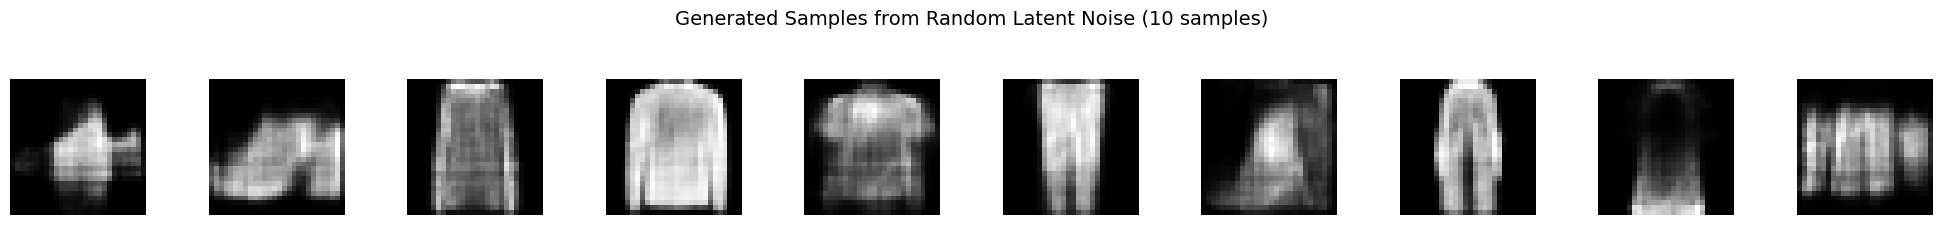

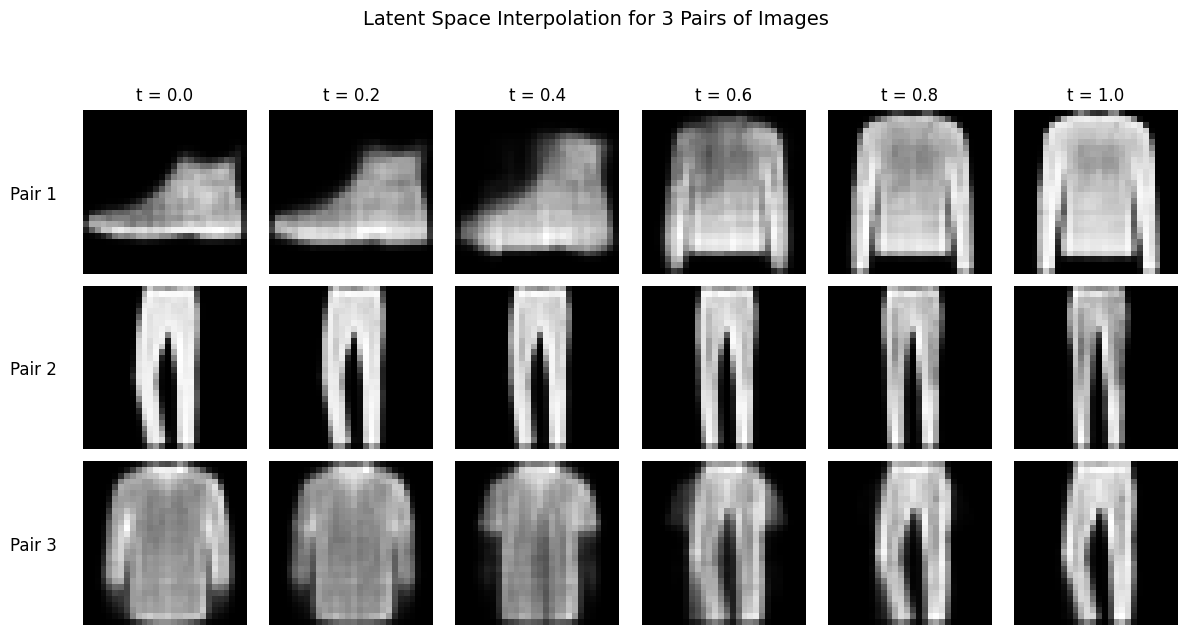

In [7]:
# Step 7: Generate at least 10 new samples by sampling from latent distribution N(0,1)
vae.eval()
with torch.no_grad():
    # simulate vector z from N(0, 1) - generating 10 samples
    z_random = torch.randn(10, 20).to(device)
    # pass z through decoder
    generated_images = vae.decode(z_random).view(-1, 28, 28).cpu().numpy()

# visualize the output x'
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    axes[i].imshow(generated_images[i], cmap='gray')
    axes[i].axis('off')
plt.suptitle('Generated Samples from Random Latent Noise (10 samples)', fontsize=14, y=1.1)
plt.tight_layout()
plt.show()


# Step 8: Perform latent space interpolation between 3 pairs of images
def interpolate_pair(model, img1, img2, t_values):
    with torch.no_grad():
        # pass x1, x2 through encoder -> get mu1, mu2
        mu1, _ = model.encode(img1.view(-1, 784).to(device))
        mu2, _ = model.encode(img2.view(-1, 784).to(device))
        
        interpolations = []
        # for t = 0, 0.2, 0.4 ... 1
        for t in t_values:
            # apply linear interpolation: z(t) = (1-t)*mu1 + t*mu2
            z_t = (1 - t) * mu1 + t * mu2
            # pass z(t) through decoder to get x'(t)
            recon = model.decode(z_t).view(28, 28).cpu().numpy()
            interpolations.append(recon)
            
    return interpolations

# Do this for at least 3 pairs of images
pairs = [
    (original_images[0], original_images[1]), # Pair 1: Ankle boot -> T-shirt
    (original_images[2], original_images[3]), # Pair 2: Trouser -> Dress
    (original_images[4], original_images[5])  # Pair 3: Shirt -> Pullover
]

# Grid between 0 and 1 (6 steps: 0.0, 0.2, 0.4, 0.6, 0.8, 1.0)
t_values = np.linspace(0, 1, 6)

# Plot all reconstructed images x'(t) for all t and all 3 pairs
fig, axes = plt.subplots(len(pairs), len(t_values), figsize=(12, 6))

for row_idx, (imgA, imgB) in enumerate(pairs):
    interp_imgs = interpolate_pair(vae, torch.tensor(imgA), torch.tensor(imgB), t_values)
    
    for col_idx, img in enumerate(interp_imgs):
        axes[row_idx, col_idx].imshow(img, cmap='gray')
        axes[row_idx, col_idx].axis('off')
        
        # Add titles only to the top row to indicate t values
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(f"t = {t_values[col_idx]:.1f}")
            
        # Add labels to the rows
        if col_idx == 0:
            axes[row_idx, col_idx].text(-5, 14, f'Pair {row_idx+1}', va='center', ha='right', fontsize=12)

plt.suptitle('Latent Space Interpolation for 3 Pairs of Images', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

**Analysis of Generative Capabilities and Latent Space Continuity:**

1. **Random Generation:** The first plot demonstrates the VAE's generative power. By decoding 10 purely random vectors sampled from a standard normal distribution ($z \sim \mathcal{N}(0, 1)$), the model successfully synthesizes entirely new, coherent clothing items (e.g., shirts, bags, and shoes). This confirms the model has accurately learned the underlying data distribution rather than just memorizing the training set.

2. **Latent Interpolation:** The 3-pair interpolation grid highlights the topological properties of the learned latent space. As the interpolation parameter $t$ progresses from $0.0$ to $1.0$, we observe a smooth, geometric morphing between fundamentally different items. For example, in Pair 1 (a shoe morphing into a pullover) and Pair 3 (a pullover morphing into trousers), the intermediate steps ($t=0.4, 0.6$) represent plausible hybrid structures rather than a simple pixelated cross-fade. This smooth structural transition proves that the VAE's latent space is continuous, dense, and free of "dead zones."

# Problem 5.3: Anomaly Detection with VAE 
## Use VAE for unsupervised anomaly detection:
- Train VAE on normal samples from credit card fraud dataset.
- Use reconstruction error as anomaly score.
- Compare with traditional anomaly detection methods (Isolation Forest,
One-Class SVM).
- Evaluate using precision-recall curves and ROC-AUC.



### 5.3.1 Dataset Preparation (Credit Card Fraud)

**Step 1:** We start by preparing the Credit Card Fraud dataset. Following the instructions:
* We drop the `Time` column, leaving us with 29 features (V1-V28 PCA components + `Amount`).
* The dataset is highly imbalanced (**99.83%** normal transactions).
* We split the data such that the training set contains **80%** of the normal samples (used to train the models on what "normal" looks like).
* The test set contains the remaining **20%** of normal samples plus **all** the fraudulent transactions.
* Finally, we standardize the features using `StandardScaler`, fitting it strictly on the training set to prevent data leakage.

In [10]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Load the dataset (Make sure 'creditcard.csv' is in your directory)
df = pd.read_csv('creditcard.csv')

# Drop the 'Time' column as instructed
df = df.drop(['Time'], axis=1)

# Separate normal and fraud data
normal_data = df[df['Class'] == 0]
fraud_data = df[df['Class'] == 1]

print(f"Total Normal: {len(normal_data)}, Total Frauds: {len(fraud_data)}")

# 2. Split 80% of normal data for training, 20% for testing
train_normal, test_normal = train_test_split(normal_data, test_size=0.2, random_state=42)

# Test set contains the remaining 20% normal + ALL frauds
test_data = pd.concat([test_normal, fraud_data])

# Extract features (X) and labels (y)
X_train = train_normal.drop(['Class'], axis=1).values
y_train = train_normal['Class'].values # All zeros

X_test = test_data.drop(['Class'], axis=1).values
y_test = test_data['Class'].values # Zeros and Ones

# 3. Apply StandardScaler (Fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=256, shuffle=True)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape} (Frauds: {sum(y_test)})")

Total Normal: 284315, Total Frauds: 492
Training set shape: (227452, 29)
Test set shape: (57355, 29) (Frauds: 492)


### 5.3.2 VAE Architecture for Tabular Data

**Step 2:** We adapt the VAE architecture for tabular data. Since our inputs are 29 continuous features scaled by `StandardScaler` (which outputs unbounded values centered around 0), **we do not use a Sigmoid activation at the end of the decoder**. The network outputs raw values.

**Step 3:** The loss function is modified accordingly. Instead of Binary Cross Entropy (used for pixels in $[0, 1]$), we use Mean Squared Error (MSE) for the reconstruction loss, combined with the standard KL Divergence.

In [11]:
# Step 2: Implement VAE appropriate for this problem
class TabularVAE(nn.Module):
    def __init__(self, input_dim=29, hidden_dim=16, latent_dim=4):
        super(TabularVAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        # NO SIGMOID AT THE END (as instructed for standardized tabular data)
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# Step 3: Train VAE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = TabularVAE(input_dim=29).to(device)

optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 15
mse_loss_fn = nn.MSELoss(reduction='sum')

print("Training VAE...")
vae.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_x, in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(batch_x)
        
        # Reconstruction Loss (MSE) + KL Divergence
        recon_loss = mse_loss_fn(recon_batch, batch_x)
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        loss = recon_loss + kld_loss
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss / len(train_loader.dataset):.4f}")

Training VAE...
Epoch 1/15 | Loss: 27.9453
Epoch 2/15 | Loss: 25.4537
Epoch 3/15 | Loss: 24.4516
Epoch 4/15 | Loss: 23.6852
Epoch 5/15 | Loss: 23.1443
Epoch 6/15 | Loss: 22.8882
Epoch 7/15 | Loss: 22.6846
Epoch 8/15 | Loss: 22.4987
Epoch 9/15 | Loss: 22.2942
Epoch 10/15 | Loss: 22.0874
Epoch 11/15 | Loss: 21.8788
Epoch 12/15 | Loss: 21.6976
Epoch 13/15 | Loss: 21.5726
Epoch 14/15 | Loss: 21.4791
Epoch 15/15 | Loss: 21.4101


### 5.3.3 Training Baseline Models

**Step 4:** To establish a benchmark, we train two traditional, unsupervised anomaly detection models from `sklearn`:
1.  **Isolation Forest:** Isolates anomalies by randomly selecting a feature and a split value. Anomalies typically require fewer splits to be isolated.
2.  **One-Class SVM:** Learns a decision boundary that encompasses the normal data points in a high-dimensional space.

*Note: Both models are trained strictly on the normal training set.*

In [12]:
# Step 4: Train Isolation Forest and One-Class SVM on training set
print("Training Isolation Forest...")
iso_forest = IsolationForest(random_state=42, n_jobs=-1)
iso_forest.fit(X_train_scaled)

print("Training One-Class SVM...")
# NOTE: OneClassSVM scales O(n^2) and might take a few minutes on ~227k samples.
oc_svm = OneClassSVM(gamma='auto')
oc_svm.fit(X_train_scaled)
print("Baseline models trained successfully.")

Training Isolation Forest...
Training One-Class SVM...
Baseline models trained successfully.


### 5.3.4 Anomaly Scoring and Evaluation

**Step 5:** We calculate the anomaly scores for the test set across all three methods. A higher score must indicate a higher probability of being an anomaly (fraud):
* **VAE:** We use the Reconstruction Error (MSE between the test sample and its reconstruction).
* **Isolation Forest:** We use `-score_samples(X_test)`. The negative sign inverts the sklearn output so that higher values represent anomalies.
* **One-Class SVM:** We use `-decision_function(X_test)` for the exact same reason.

**Step 6 & 7:** We plot the ROC (Receiver Operating Characteristic) curve and the Precision-Recall (PR) curve for each method, calculating their respective Areas Under the Curve (AUC).

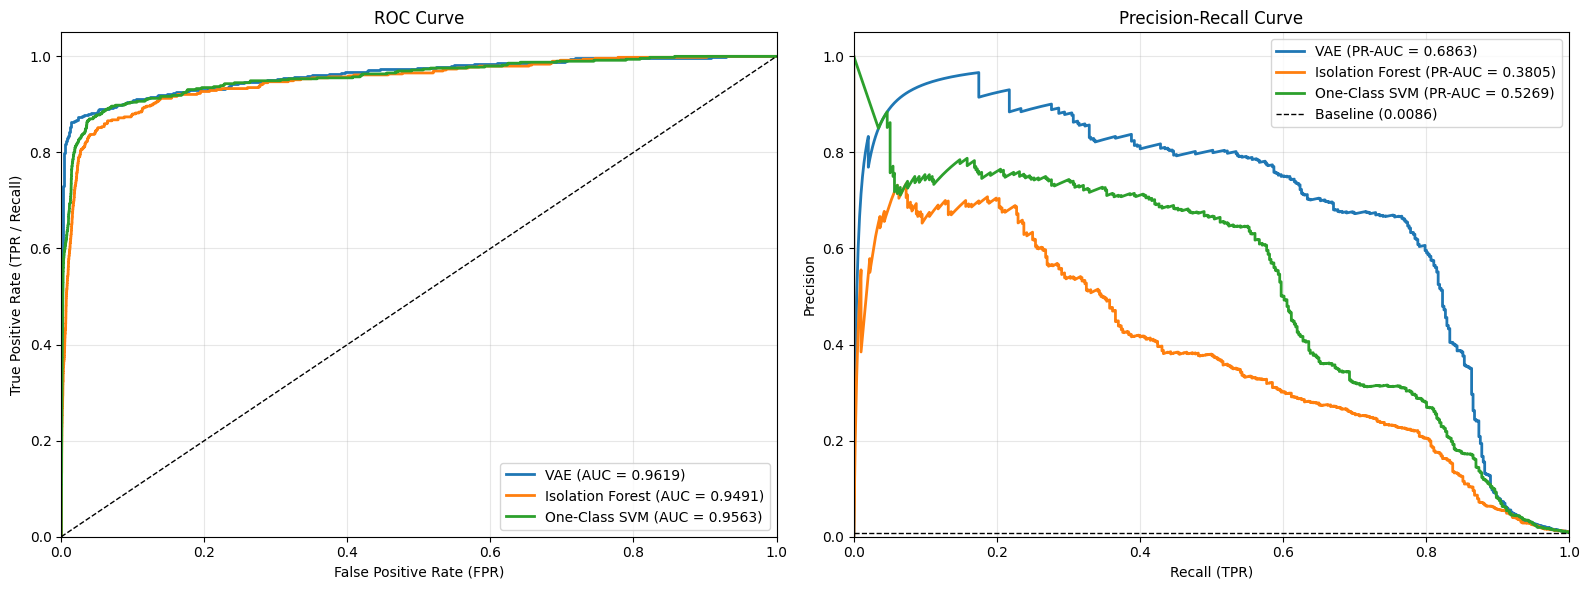

In [13]:
# Step 5: Get anomaly scores for test set
vae.eval()
with torch.no_grad():
    X_test_tensor_gpu = X_test_tensor.to(device)
    recon_test, _, _ = vae(X_test_tensor_gpu)
    recon_test = recon_test.cpu().numpy()

# 1. VAE Anomaly Score: MSE between observation and its reconstruction (per sample)
vae_scores = np.mean(np.square(X_test_scaled - recon_test), axis=1)

# 2. Isolation Forest Score
if_scores = -iso_forest.score_samples(X_test_scaled)

# 3. One-Class SVM Score
svm_scores = -oc_svm.decision_function(X_test_scaled)

# Combine scores into a dictionary for easy plotting
models_scores = {
    'VAE': vae_scores,
    'Isolation Forest': if_scores,
    'One-Class SVM': svm_scores
}

# Step 6 & 7: Plot ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC Curves
for name, scores in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR / Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Plot Precision-Recall Curves
for name, scores in models_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {pr_auc:.4f})')

# Baseline for PR curve (ratio of positives in the test set)
baseline = sum(y_test) / len(y_test)
axes[1].plot([0, 1], [baseline, baseline], color='black', lw=1, linestyle='--', label=f'Baseline ({baseline:.4f})')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (TPR)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis of Anomaly Detection Performance:**

1. **ROC Curve (ROC-AUC):** The ROC curve evaluates the trade-off between the True Positive Rate (Recall) and the False Positive Rate. All three models perform exceptionally well here, with the VAE slightly leading (AUC = 0.9619). However, in highly imbalanced datasets (like credit card fraud, where anomalies are < 1%), ROC-AUC can be overly optimistic. The massive number of True Negatives artificially keeps the FPR very low, masking false positive errors.

2. **Precision-Recall Curve (PR-AUC):** The PR curve is the definitive and most objective metric for highly imbalanced datasets because it completely ignores True Negatives and focuses entirely on the minority class (frauds). The baseline for this dataset is extremely low (0.0086), highlighting the difficulty of the task.

3. **Model Comparison & Conclusion:** On the PR curve, the VAE establishes absolute dominance with a PR-AUC of 0.6863, vastly outperforming both the One-Class SVM (0.5269) and the Isolation Forest (0.3805). This proves that the VAE's deep, non-linear architecture is far superior at learning the complex underlying manifold of "normal" transactions. When a fraudulent transaction is passed through the network, the VAE fails to reconstruct its unseen structural anomalies, resulting in a significantly higher and highly discriminative Mean Squared Error (MSE) score.